#SUPPORT VECTOR MACHINE

Dataset Selection:

Task 1: Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
# 1.Load the dataset and perform fundamental data exploration.

In [4]:
df=pd.read_csv('Pharma_Industry.csv')

In [5]:
df.head()


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [7]:
### handling missing data
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [8]:
## no missing data to handle

In [9]:
## checking for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
## there is no duplicated data

skewness of Drug Dosage (mg) is: -0.12434657168544438
skewness of Systolic Blood Pressure (mmHg) is: 0.21461744723410245
skewness of Heart Rate (BPM) is: 0.11966706396699081
skewness of Liver Toxicity Index (U/L) is: 0.3999788172412866
skewness of Blood Glucose Level (mg/dL) is: -0.21037352492144681
skewness of Drug Response is: -0.08030519352763103


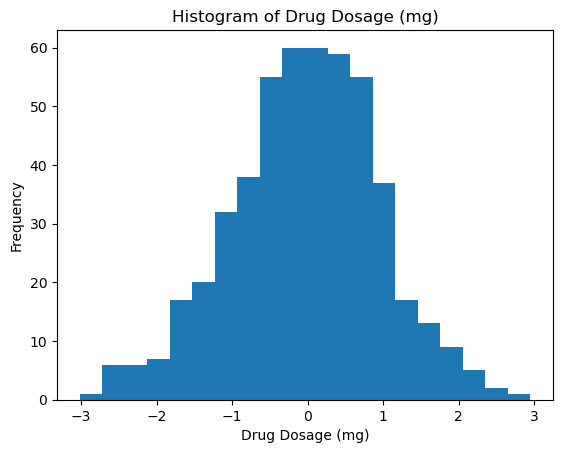

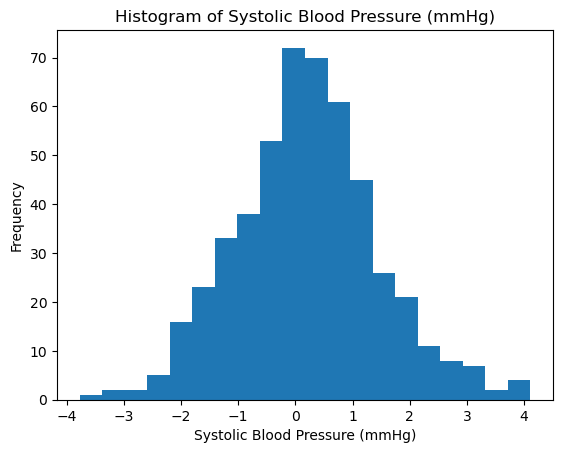

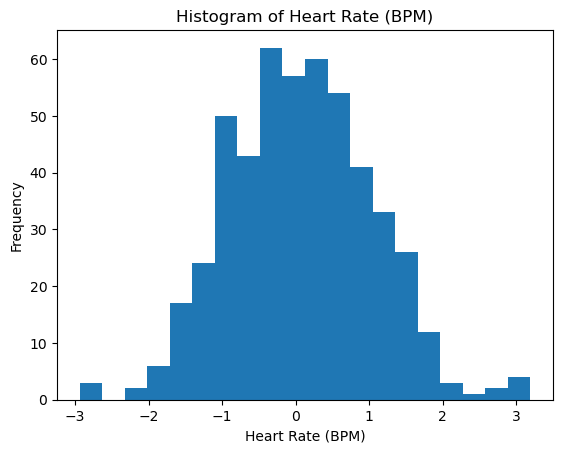

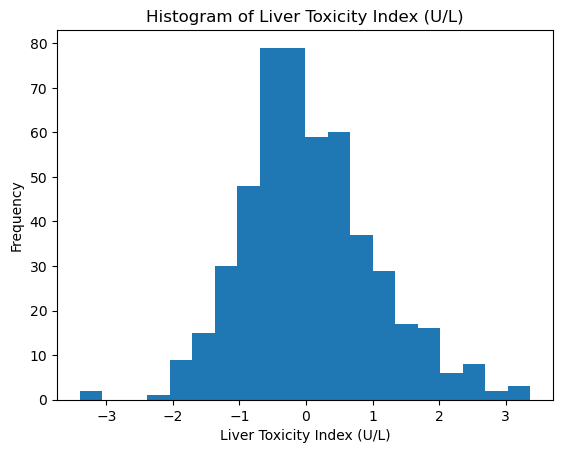

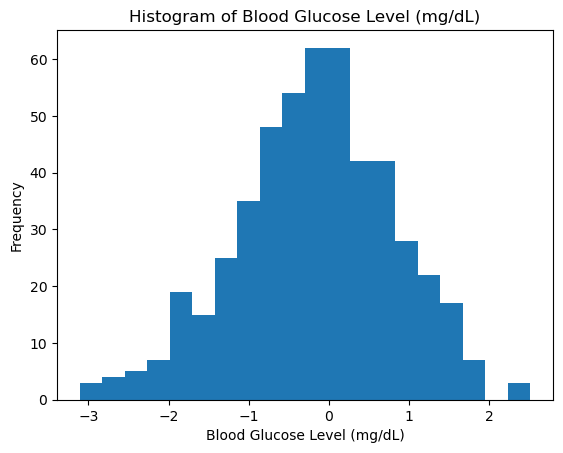

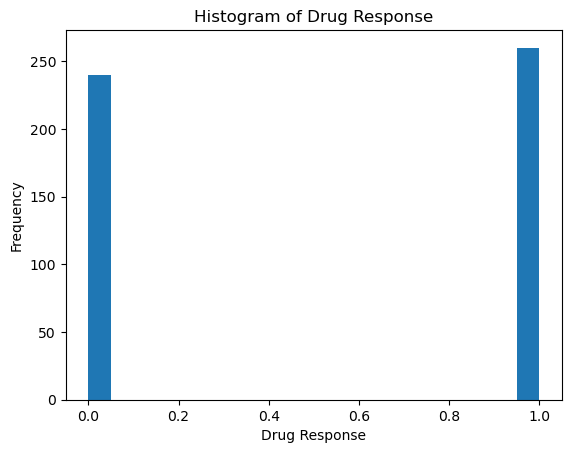

In [11]:
## histogram
for col in df:
    skewness = df[col].skew()
    print(f"skewness of {col} is:",skewness)
for col in df:
    plt.hist(df[col],bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

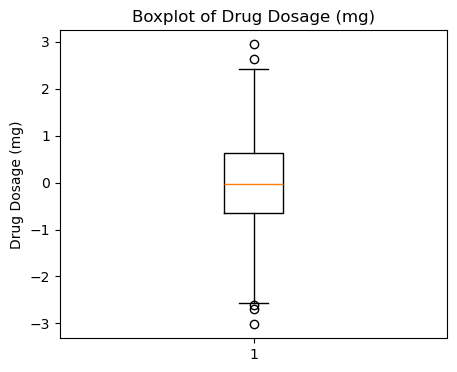

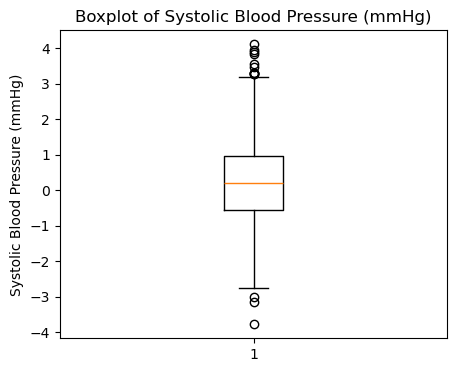

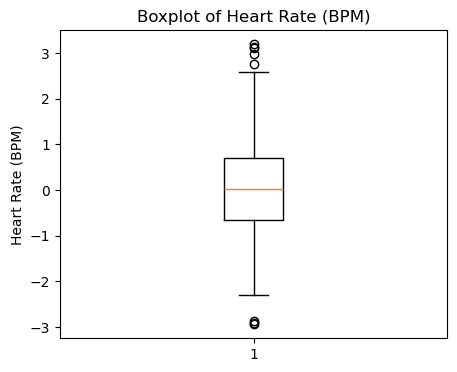

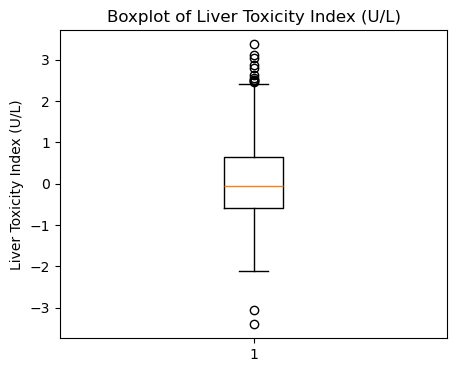

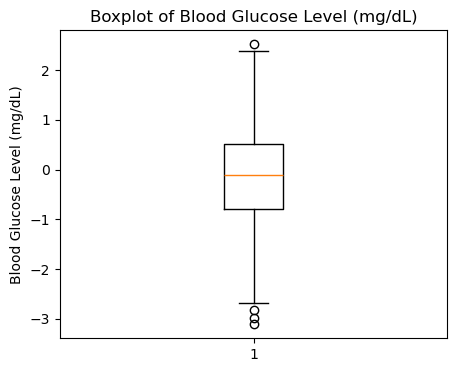

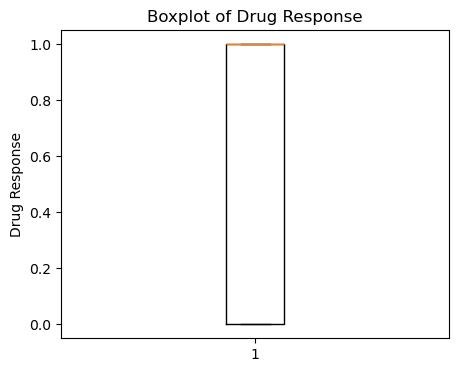

In [12]:
### outlier decting
for col in df:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [13]:
## outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)


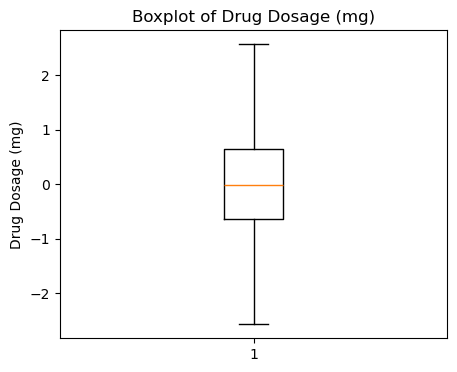

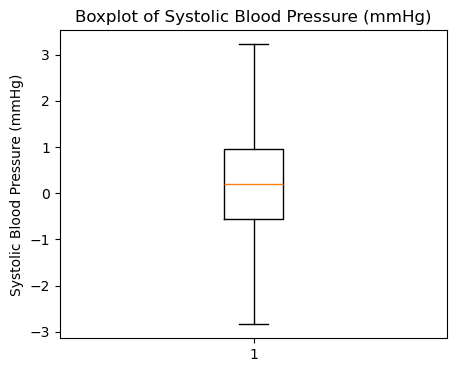

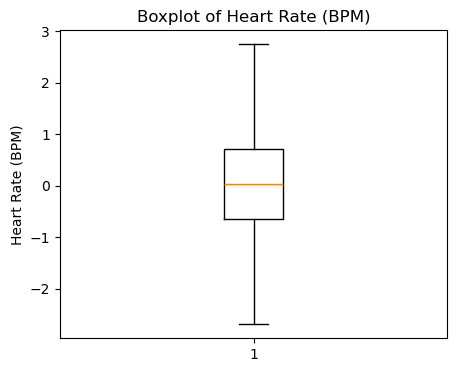

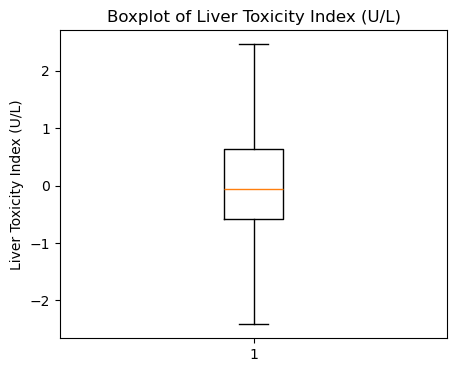

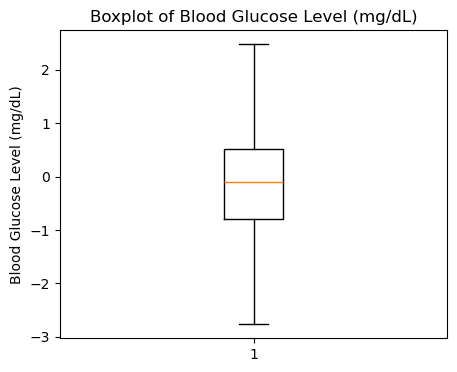

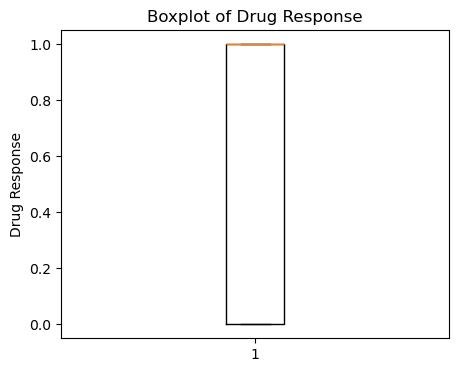

In [14]:
### outlier decting after outlier-capping 
for col in df:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [15]:
#### now, there are no outliers

In [21]:
## from the above skewness code skewness for all columns:
#skewness of Drug Dosage (mg) is: -0.12077582726816093
#skewness of Systolic Blood Pressure (mmHg) is: 0.15846553058044358
#skewness of Heart Rate (BPM) is: 0.08576836406085926
#skewness of Liver Toxicity Index (U/L) is: 0.37710177865138506
#skewness of Blood Glucose Level (mg/dL) is: -0.18834219806276212
#skewness of Drug Response is: -0.08030519352763103
### data(feature) is moderately normally distributed with slighly negative and slightly positive skew.

3.	Investigate feature correlations to discern relationships within the data.

In [22]:
#1. Selecting Numerical Features
df_numerical = df.select_dtypes(include=['int','float64']).columns

In [23]:
print(df_numerical)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


In [24]:
df_categorial = df.select_dtypes('object','character')

In [25]:
df_categorial.columns

Index([], dtype='object')

In [26]:
# 2. Compute Correlation Matrix
corr_matrix = df[df_numerical].corr()
print(corr_matrix)

                                Drug Dosage (mg)  \
Drug Dosage (mg)                        1.000000   
Systolic Blood Pressure (mmHg)          0.087760   
Heart Rate (BPM)                        0.040512   
Liver Toxicity Index (U/L)              0.128059   
Blood Glucose Level (mg/dL)             0.010070   
Drug Response                           0.043340   

                                Systolic Blood Pressure (mmHg)  \
Drug Dosage (mg)                                      0.087760   
Systolic Blood Pressure (mmHg)                        1.000000   
Heart Rate (BPM)                                     -0.041466   
Liver Toxicity Index (U/L)                            0.273864   
Blood Glucose Level (mg/dL)                           0.041263   
Drug Response                                         0.308012   

                                Heart Rate (BPM)  Liver Toxicity Index (U/L)  \
Drug Dosage (mg)                        0.040512                    0.128059   
Systolic Blo

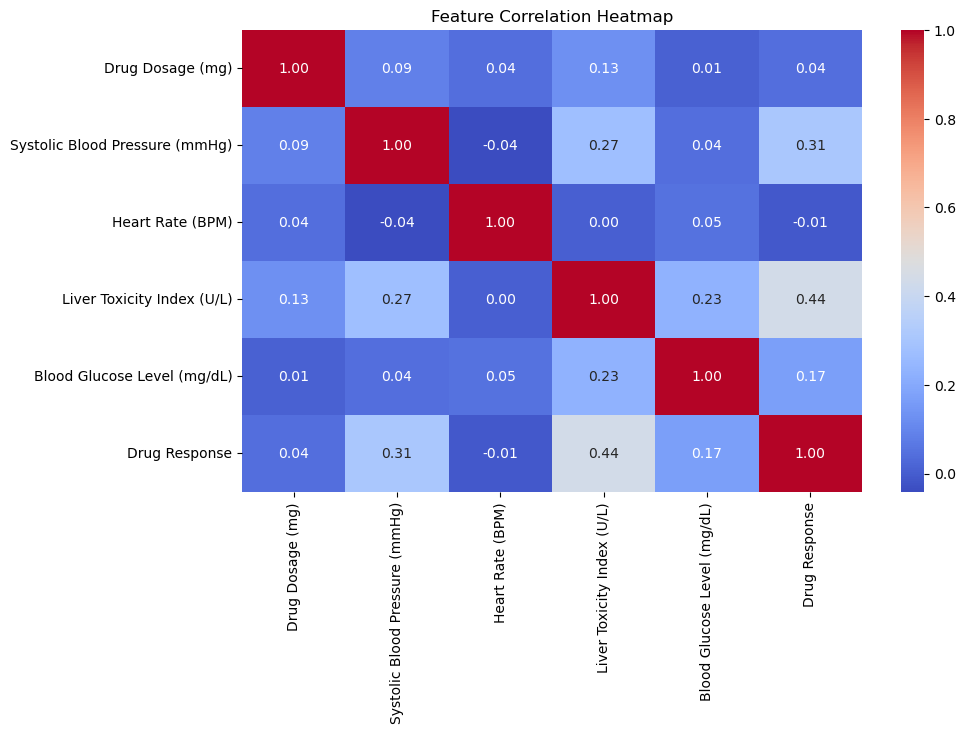

In [27]:
# 3. Plot Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()


Task 2: Data Preprocessing

1.	Encode categorical variables if necessary.

In [28]:
# 1. Encode Categorical Variables
#Label Encoding – assigns a unique number to each category.
#One-Hot Encoding – creates binary columns for each category.
from sklearn.preprocessing import LabelEncoder

In [29]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols)

Categorical Columns: Index([], dtype='object')


In [30]:
# As there is no categorial data, encoding is not needed.

In [31]:
# 2.	Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

In [32]:
## features and target selection
features = df.drop("Drug Response", axis=1)  # Features
target   = df["Drug Response"]               # Target


In [33]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [34]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
   
print("X_train:\n", X_train.shape)
print("X_test:\n", X_test.shape)
print("y_train:\n", y_train.shape)
print("y_test:\n", y_test.shape)

X_train:
 (400, 5)
X_test:
 (100, 5)
y_train:
 (400,)
y_test:
 (100,)


Task 3: Data Visualization

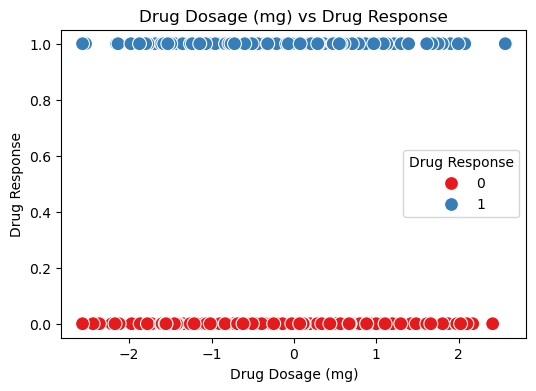

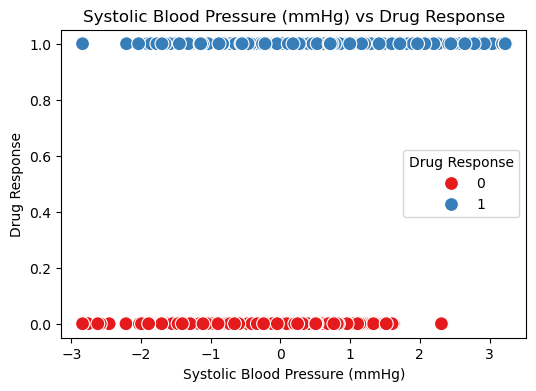

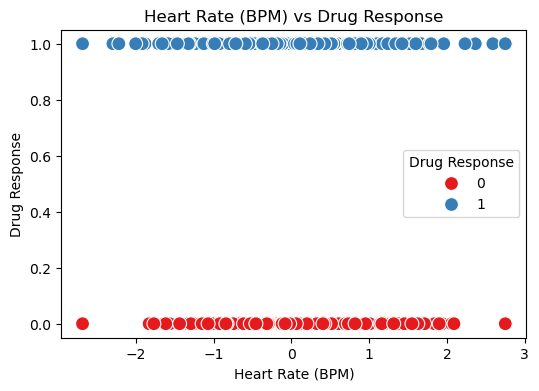

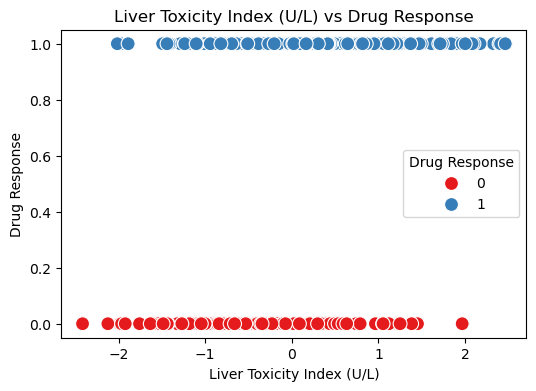

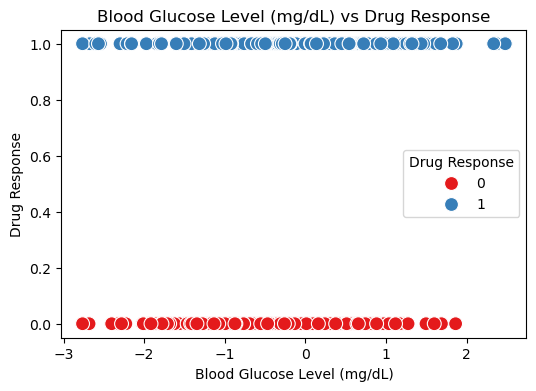

In [35]:
# 1.Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

# Scatter plots (feature vs target)
# Plot each feature vs Drug Response
for col in df.columns[:-1]:  # exclude target
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df["Drug Response"], hue=df["Drug Response"], palette="Set1", s=100)
    plt.title(f"{col} vs Drug Response")
    plt.show()

# Drug Response '0' means no response, '1' means positive response.

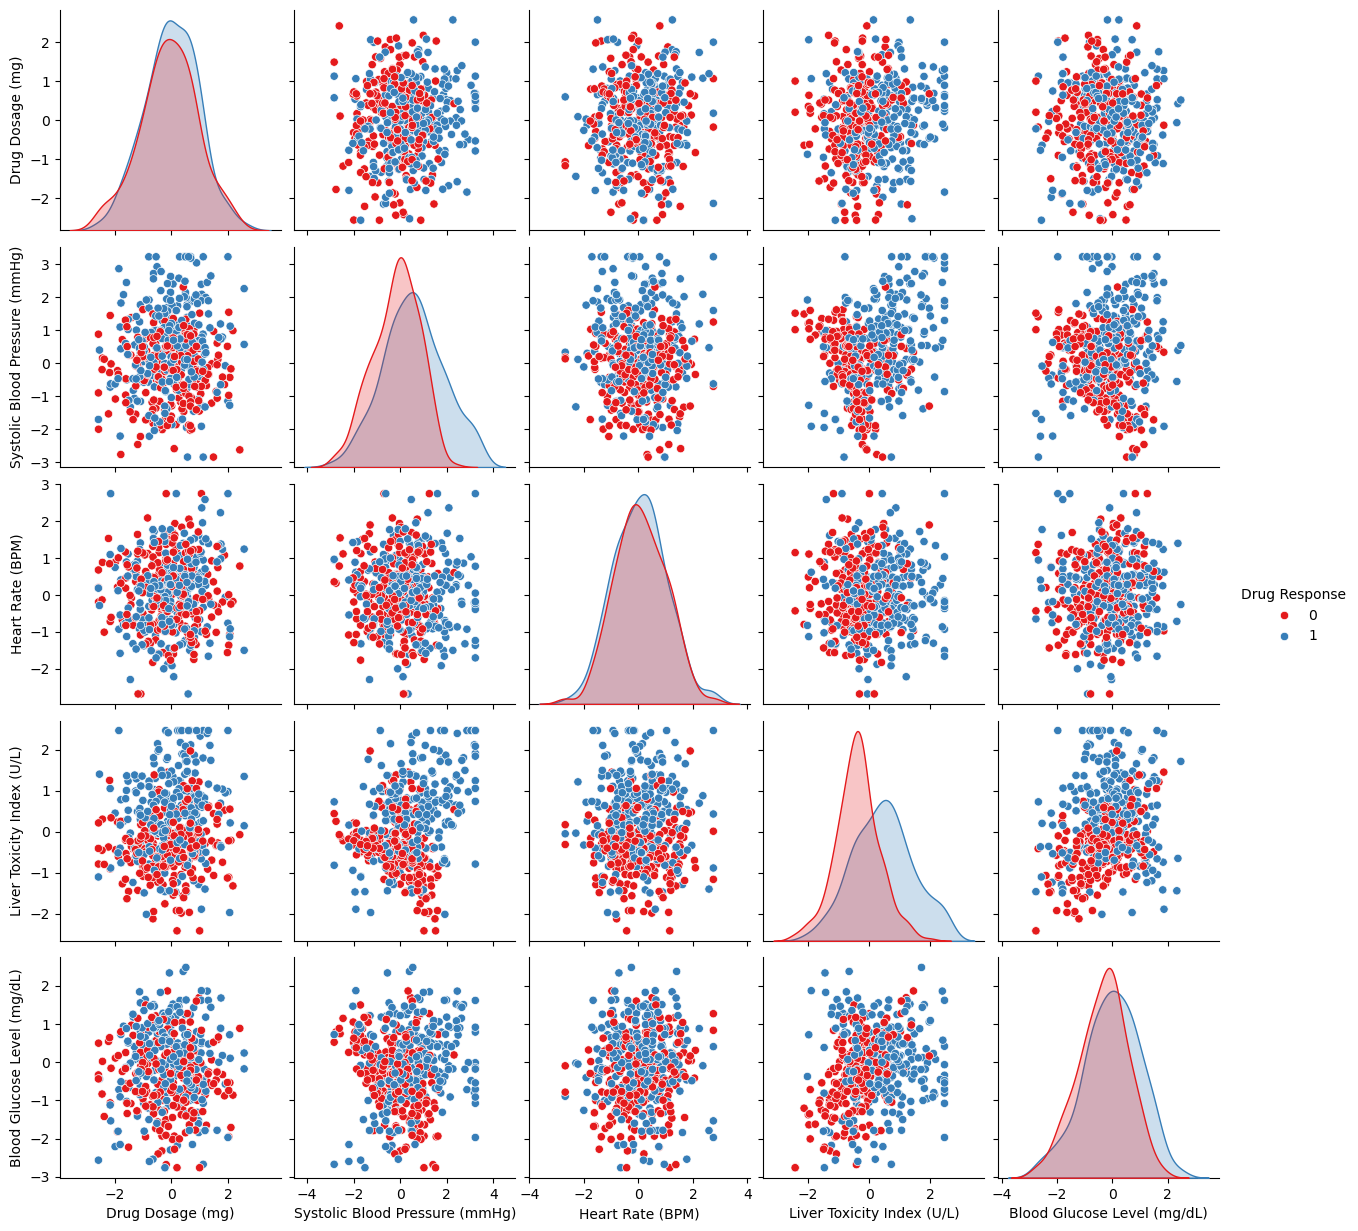

In [37]:
# Pair plot (all feature relationships)
sns.pairplot(df, hue="Drug Response", palette="Set1", diag_kind="kde")
plt.show()

In [38]:
# 2.Visualize class distributions to gauge dataset balance or imbalance.

# Count the classes
class_counts = df["Drug Response"].value_counts()
print(class_counts)


Drug Response
1    260
0    240
Name: count, dtype: int64


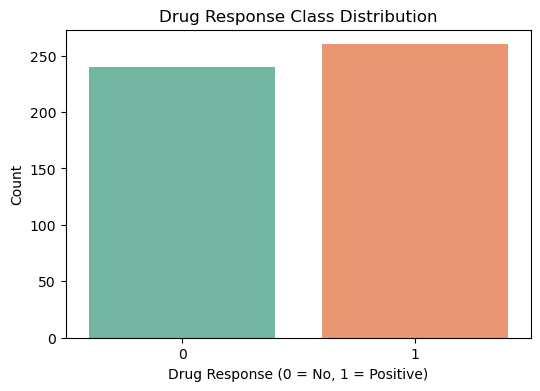

In [39]:
# Bar plot of class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Drug Response", data=df, palette="Set2")
plt.title("Drug Response Class Distribution")
plt.xlabel("Drug Response (0 = No, 1 = Positive)")
plt.ylabel("Count")
plt.show()

In [40]:
# Class '0' and '1' are roughly equal, so the dataset balanced data set

Task 4: SVM Implementation

In [41]:
#1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [44]:
# Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)


In [45]:
# Initialize and train the SVM classifier
# Create SVM classifier (linear kernel for simplicity)
svm_model = SVC(kernel='linear', random_state=42)


In [46]:
# 2. Train the SVM model on the training data.
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [47]:
# Make predictions
y_pred = svm_model.predict(X_test)

In [48]:
# 3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification report (precision, recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.72

Confusion Matrix:
 [[37 11]
 [17 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



Task 5: Visualization of SVM Results

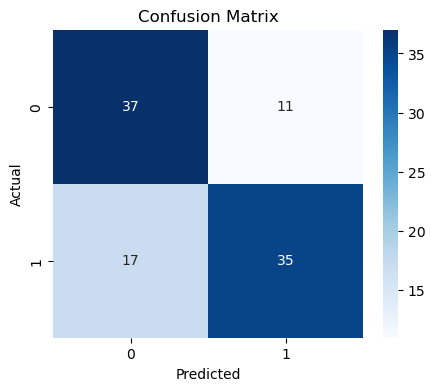

In [49]:
#1.Visualize classification results on the testing data.
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

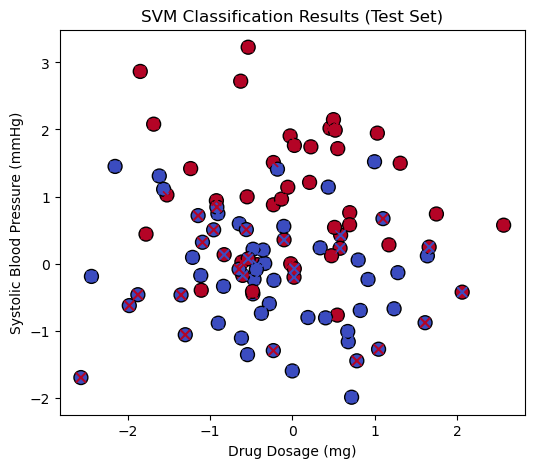

In [51]:
# Scatter plot of testing data
# We’ll use two features to visualize: Drug Dosage (mg) vs Systolic Blood Pressure (mmHg):
plt.figure(figsize=(6,5))
plt.scatter(
    X_test["Drug Dosage (mg)"], 
    X_test["Systolic Blood Pressure (mmHg)"], 
    c=y_pred,  # predicted class color
    cmap="coolwarm", 
    s=100, edgecolor='k')

plt.scatter(
    X_test["Drug Dosage (mg)"], 
    X_test["Systolic Blood Pressure (mmHg)"], 
    c=y_test,  # actual class markers
    cmap="coolwarm", 
    s=50, 
    marker='x')

plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Systolic Blood Pressure (mmHg)")
plt.title("SVM Classification Results (Test Set)")
plt.show()


Task 6: Parameter Tuning and Optimization

In [54]:
# 1.Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.
# Define hyperparameter grid
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']  # relevant for 'rbf' and 'poly'
}

In [55]:
# Grid search for best parameters
svm = SVC(random_state=42)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=3,            # 3-fold cross-validation
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [56]:
# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [58]:
# Evaluate optimized model
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.76        48
           1       0.77      0.83      0.80        52

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



Task 7: Comparison and Analysis

In [60]:
#1.Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
# Train SVMs with different kernels
kernels = ['linear', 'poly', 'rbf']
results = {}

for k in kernels:
    svm = SVC(kernel=k, C=1, gamma='scale', random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[k] = acc
    print(f"Kernel: {k}")
    print(f"Accuracy: {acc:.2f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*50)

Kernel: linear
Accuracy: 0.72
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100

--------------------------------------------------
Kernel: poly
Accuracy: 0.69
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.73      0.69        48
           1       0.72      0.65      0.69        52

    accuracy                           0.69       100
   macro avg       0.69      0.69      0.69       100
weighted avg       0.69      0.69      0.69       100

--------------------------------------------------
Kernel: rbf
Accuracy: 0.78
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.7

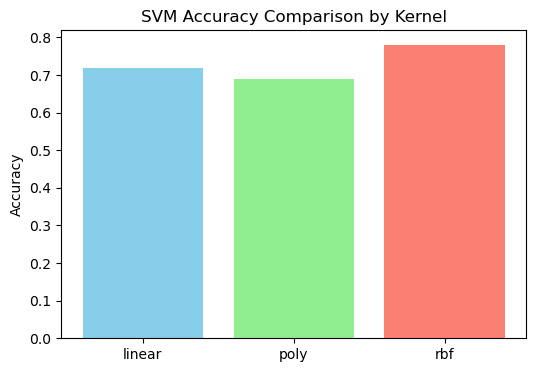

In [61]:
# Compare kernel performance
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values(), color=['skyblue','lightgreen','salmon'])
plt.ylabel("Accuracy")
plt.title("SVM Accuracy Comparison by Kernel")
plt.show()

In [62]:
# 2.Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results

# Strengths of SVM for this Dataset

# Works well with small-to-medium datasets : our dataset is small, so SVM can handle it without requiring a huge amount of data.
# Handles high-dimensional data :  Even with multiple features, SVM can find the optimal separating hyperplane.
# Effective with overlapping classes using kernels : Using rbf or poly kernels allows SVM to capture nonlinear relationships where simple linear
                                                      #separation isn’t possible.
# Robust to outliers (with regularization C): The C parameter lets you control the trade-off between margin width and misclassification, 
                                               #which helps manage noisy points.


In [64]:
# Weaknesses / Challenges of SVM for this Dataset:

#Sensitive to small sample size: With only 5 samples, SVM may overfit, especially with complex kernels like rbf or poly.
# Imbalanced class problem : More positive responses than negatives; SVM may bias predictions toward the majority class without
                              # stratification or class weighting.
#Choice of hyperparameters is crucial : Parameters like C, gamma, and kernel heavily affect performance; wrong choice can underfit or overfit.
# Difficult to interpret for non-linear kernels : Linear SVM is interpretable via coefficients, but RBF/poly kernels produce 
                                                  #complex boundaries that are hard to visualize in high dimensions.
#Not probabilistic by default :SVM outputs class labels but not probabilities (needs probability=True), 
                                #which may be useful in medical/drug response applications.

3.	Discuss practical implications of SVM in real-world classification tasks.

Practical Implications of SVM:
SVM is a powerful classifier for high-dimensional or moderately sized datasets, capable of handling both linear and nonlinear 
relationships using kernel functions. It is effective in applications like medical diagnosis, fraud detection, and text classification. 
SVM requires careful feature scaling, hyperparameter tuning, and management of class imbalances, and nonlinear kernels may reduce interpretability. 
Enabling probability estimates can improve decision-making in risk-sensitive tasks.